<a href="https://colab.research.google.com/github/num153/Sentiment-analys/blob/main/Ph%C3%A2n_t%C3%ADch_c%E1%BA%A3m_x%C3%BAc_main.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install underthesea

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.4 MB/s eta 0:00:00


In [2]:
import re
import unicodedata
import pandas as pd
# 1. Tải các file cần thiết từ GitHub về Colab
!wget -O slang_words.txt https://raw.githubusercontent.com/num153/Sentiment-analys/main/data/slang_words.txt
!wget -O vietnamese-stopwords.txt https://raw.githubusercontent.com/num153/Sentiment-analys/main/data/vietnamese-stopwords.txt
!wget -O dataset.csv https://raw.githubusercontent.com/num153/Sentiment-analys/main/data/dataset.csv
!wget -O synonyms_vi.csv https://raw.githubusercontent.com/num153/Sentiment-analys/main/data/synonyms_vi.csv

print("--- Đã tải xong toàn bộ dữ liệu từ GitHub! ---")

--2026-08-27 04:51:33--  https://raw.githubusercontent.com/num153/Sentiment-analys/main/data/slang_words.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815 [text/plain]
Saving to: ‘slang_words.txt’

slang_words.txt     100%[===================>]     815  --.-KB/s    in 0s      

2026-08-27 04:51:33 (54.3 MB/s) - ‘slang_words.txt’ saved [815/815]

--2026-08-27 04:51:33--  https://raw.githubusercontent.com/num153/Sentiment-analys/main/data/vietnamese-stopwords.txt
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 450 [text/plain]

In [3]:
def load_slang_dict(filepath="slang_words.txt"):
    slang_words = {}
    with open(filepath, "r", encoding="utf-8") as file:
        for line in file:
            line = line.strip()
            if " : " in line:
                slang, replacement = line.split(" : ", 1)
                slang_words[slang] = replacement
    return slang_words

In [4]:
def load_synonyms(filepath="synonyms_vi_clean.csv"):
    """
    Đọc file từ đồng nghĩa tiếng Việt.
    Format CSV: word,synonyms  (synonyms phân cách bằng dấu ';')

    Trả về dict dạng:
        {từ_gốc: [syn1, syn2, ...]}   ← tra theo từ chuẩn
    VÀ mapping ngược:
        {synonym: từ_gốc}             ← chuẩn hóa bất kỳ synonym → từ gốc
    """
    canonical = {}   # từ gốc → list synonyms
    reverse   = {}   # synonym → từ gốc

    with open(filepath, "r", encoding="utf-8") as f:
        next(f)  # bỏ header "word,synonyms"
        for line in f:
            line = line.strip()
            if not line:
                continue
            parts = line.split(",", 1)
            if len(parts) < 2:
                continue
            word, syns_raw = parts
            word = word.strip().lower().replace(" ", "_")
            synonyms = []
            for s in syns_raw.split(";"):
                s_clean = s.strip().lower().replace(" ", "_") # Quan trọng nhất ở đây
                if s_clean:
                    synonyms.append(s_clean)
                    # 4. Mapping ngược: synonym -> từ gốc
                    reverse[s_clean] = word
            canonical[word] = synonyms
            # for syn in synonyms:
            #     reverse[syn] = word
    return canonical, reverse

def load_stopwords(filepath="vietnamese-stopwords.txt"):
  """
  Đọc file stopwords tiếng Việt.
  Mỗi dòng là một stopword/cụm stopword.
  Trả về set để tra cứu O(1).
  """
  stopwords = set()
  with open(filepath, "r", encoding="utf-8") as f:
      for line in f:
          word = line.strip()
          if word:
              stopwords.add(word)
  return stopwords

In [5]:
slang_dict           = load_slang_dict()
stopwords_vi         = load_stopwords("vietnamese-stopwords.txt")
synonym_dict, reverse_synonym = load_synonyms("synonyms_vi.csv")

In [6]:
import re
import unicodedata
from underthesea import word_tokenize

def clean_text(text):
    if pd.isna(text) or str(text).strip() == "":
        return ""

    text = str(text).strip()

    # Bước 1: Chuẩn hóa Unicode
    text = unicodedata.normalize("NFC", text)

    # Bước 2: Lowercase
    text = text.lower()

    # Bước 3: Xóa URL
    text = re.sub(r'http[s]?://\S+', ' ', text)

    # Bước 4: Xóa email
    text = re.sub(r'\b[\w\.-]+@[\w\.-]+\.\w+\b', ' ', text)

    # Bước 5: Xóa số điện thoại (10-11 số liên tiếp)
    text = re.sub(r'(?<!\d)\d{10,11}(?!\d)', ' ', text)

    # Bước 6: Xóa HTML tags, @mention, #hashtag
    text = re.sub(r'<.*?>', ' ', text)
    text = re.sub(r'[@#]\w+', ' ', text)

    # Bước 7: Xóa emoji và ký tự đặc biệt ngoài bảng Latin + tiếng Việt
    text = re.sub(r'[^\s\wáàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệ'
                  r'óòỏõọôốồổỗộơớờởỡợíìỉĩịúùủũụưứừửữự'
                  r'ýỳỷỹỵđ]', ' ', text)

    # Bước 8: Xóa toàn bộ số
    text = re.sub(r'\d+', ' ', text)

    # Bước 9: Chuẩn hóa teencode từ slang_dict
    # words = text.split()
    tokens = word_tokenize(text)
    words = [t.replace(" ", "_") for t in tokens]
    words = [slang_dict.get(w, w) for w in words]


    # Bước 10: Xóa ký tự lặp quá 2 lần (vd: "nhanhhhhh" → "nhanh")
    words = [re.sub(r'(.)\1{2,}', r'\1', w) for w in words]

    # Bước 11: Chuẩn hóa synonym → từ gốc
    words = [reverse_synonym[w] if w in reverse_synonym
             and len(reverse_synonym[w].split()) == 1  # ✅ chỉ map 1→1 token
             else w
             for w in words]

    # Bước 12: Xóa stopwords (từ file) + từ quá ngắn
    words = [w for w in words if w not in stopwords_vi and len(w) > 1]

    # Bước 13: Xóa khoảng trắng thừa
    return re.sub(r'\s+', ' ', ' '.join(words)).strip()

In [7]:
test_sentences = [
    "Hàng freeship ngonnnnn, ko tốn tiền ship v",
    "SĐT liên hệ 0901234567 hoặc qua mail test@gmail.com",
    "Mua máy tính bảng tặng kèm smartphone cực xịn!!!",
    "Ghé thăm https://google.com để biết thêm chi tiết #sale",
    "Sản phẩm này rất là tuyệt vời và đỉnhhhhh và xinh đẹp làm tôi rất vui vẻ"
]

print(f"{'Văn bản gốc':<50} | {'Sau khi xử lý'}")
print("-" * 100)

for sent in test_sentences:
    cleaned = clean_text(sent)
    print(f"{sent:<50} | {cleaned}")

Văn bản gốc                                        | Sau khi xử lý
----------------------------------------------------------------------------------------------------
Hàng freeship ngonnnnn, ko tốn tiền ship v         | hàng miễn_phí vận_chuyển ngon không tốn tiền giao_hàng
SĐT liên hệ 0901234567 hoặc qua mail test@gmail.com | sđt liên_hệ hoặc mail
Mua máy tính bảng tặng kèm smartphone cực xịn!!!   | mua máy_tính bảng tặng kèm smartphone cực xịn
Ghé thăm https://google.com để biết thêm chi tiết #sale | ghé thăm biết thêm chi_tiết
Sản phẩm này rất là tuyệt vời và đỉnhhhhh và xinh đẹp làm tôi rất vui vẻ | sản_phẩm tốt đỉnh đẹp làm tôi vui


In [8]:
df = pd.read_csv("dataset.csv")
print(df.shape)
df.head()

df["comment_clean"] = df["comment"].apply(clean_text)

for i, row in df.head(10).iterrows():
    print(f"ORIGINAL : {row['comment']}")
    print(f"CLEANED  : {row['comment_clean']}")
    print(f"LABEL    : {row['label']} | RATE: {row['rate']}")
    print()

(51535, 3)
ORIGINAL : Áo bao đẹp ạ!!
CLEANED  : áo bao đẹp
LABEL    : POS | RATE: 5

ORIGINAL : Tuyệt vời !
CLEANED  : tốt
LABEL    : POS | RATE: 5

ORIGINAL : 2day ao khong giong trong.
CLEANED  : day ao khong_giong trong
LABEL    : NEG | RATE: 1

ORIGINAL : Mùi thơm,bôi lên da mềm da.
CLEANED  : mùi thơm bôi da mềm da
LABEL    : POS | RATE: 5

ORIGINAL : Vải đẹp, dày dặn.
CLEANED  : vải đẹp dày dặn
LABEL    : POS | RATE: 5

ORIGINAL : Hàng rất đẹp, rất chi là ưng ý.
CLEANED  : hàng đẹp chi hài_lòng
LABEL    : POS | RATE: 5

ORIGINAL : Chất lượng sản phẩm tốt, date dài.
CLEANED  : chất_lượng sản_phẩm tốt date dài
LABEL    : POS | RATE: 5

ORIGINAL : Ăn nói và thái độ phục vụ tốt.
CLEANED  : ăn_nói thái_độ phục_vụ tốt
LABEL    : POS | RATE: 4

ORIGINAL : Đóng gói sản phẩm chắc chắn.
CLEANED  : đóng_gói sản_phẩm chắc_chắn
LABEL    : POS | RATE: 5

ORIGINAL : tất sờn hết ca chưa dùng mà vay r.
CLEANED  : tất_sờn hết ca dùng vay
LABEL    : NEG | RATE: 2



In [9]:

#  HUẤN LUYỆN (TRAIN) AI

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.pipeline import Pipeline
import pickle
import numpy as np


# --- 4.1: Tách dữ liệu thành tập Train và Test ---

mask = df['comment_clean'].str.strip().str.len() > 0
X = df.loc[mask, 'comment_clean']
y = df.loc[mask, 'label']

print(f"📊 Tổng mẫu sau lọc: {len(X)}")
print(f"📊 Phân bố nhãn:\n{y.value_counts().to_string()}\n")


# X = df['comment_clean']  # ← đổi từ 'clean_review' thành 'comment_clean'
# y = df['label']          # POS / NEG

# # Bỏ các dòng comment_clean bị rỗng sau tiền xử lý
# mask = X.str.strip().str.len() > 0
# X, y = X[mask], y[mask]







min_class_count = y.value_counts().min()

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y if min_class_count >= 2 else None
)

print(f"📦 Train: {len(X_train)} mẫu | Test: {len(X_test)} mẫu")
print(f"📊 Phân bố nhãn train:\n{y_train.value_counts().to_string()}")









📊 Tổng mẫu sau lọc: 51400
📊 Phân bố nhãn:
label
POS    20008
NEG    16694
NEU    14698

📦 Train: 41120 mẫu | Test: 10280 mẫu
📊 Phân bố nhãn train:
label
POS    16006
NEG    13355
NEU    11759


In [10]:
pipeline = Pipeline([
    ('tfidf', TfidfVectorizer(
        ngram_range=(1, 2),
        max_features=10_000,
        sublinear_tf=True,
        min_df=2,
        max_df=0.95
    )),
    ('clf', LogisticRegression(
        max_iter=1000,
        C=1.0,
        class_weight='balanced',
        n_jobs=-1,
    ))
])





pipeline.fit(X_train, y_train)
y_pred = pipeline.predict(X_test)

print(f"\n✅ Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"\n📋 Classification Report:\n{classification_report(y_test, y_pred)}")
print(f"\n🔢 Confusion Matrix:\n{confusion_matrix(y_test, y_pred)}")



✅ Accuracy : 0.8629

📋 Classification Report:
              precision    recall  f1-score   support

         NEG       0.87      0.91      0.89      3339
         NEU       0.84      0.76      0.80      2939
         POS       0.87      0.90      0.88      4002

    accuracy                           0.86     10280
   macro avg       0.86      0.86      0.86     10280
weighted avg       0.86      0.86      0.86     10280


🔢 Confusion Matrix:
[[3033  179  127]
 [ 275 2234  430]
 [ 162  236 3604]]


In [11]:
# # --- 4.2: TF-IDF ---
# tfidf = TfidfVectorizer(
#     ngram_range=(1, 2),
#     max_features=10000,
#     sublinear_tf=True,
#     min_df=3,
#     max_df=0.9
# )

# X_train_tfidf = tfidf.fit_transform(X_train)
# X_test_tfidf  = tfidf.transform(X_test)

# print(f"📐 Ma trận TF-IDF: {X_train_tfidf.shape[0]} reviews × {X_train_tfidf.shape[1]} features")

# # --- 4.3: Logistic Regression ---
# model = LogisticRegression(
#     max_iter=1000,
#     C=1.0,
#     class_weight='balanced'
# )
# model.fit(X_train_tfidf, y_train)
# print("✅ Train xong!")

# # --- 4.4: Đánh giá model ---
# y_pred = model.predict(X_test_tfidf)

# print(f"\n🎯 Accuracy: {accuracy_score(y_test, y_pred)*100:.1f}%")
# print("\n📋 Classification Report:")
# print(classification_report(
#     y_test,
#     y_pred,
#     labels=['NEG', 'POS', 'NEU'],       # ← đổi thành POS/NEG
#     target_names=['Tiêu cực', 'Tích cực','Trung tính'],
#     zero_division=0
# ))

# # --- 4.5: Confusion Matrix ---
# print("📊 Confusion Matrix (hàng=thực tế, cột=dự đoán):")
# print(f"{'':18} {'NEG':>8} {'NEU':>8} {'POS':>8}")
# cm = confusion_matrix(y_test, y_pred, labels=['NEG', 'NEU', 'POS'])
# for label, row in zip(['Thực tế NEG', 'Thực tế NEU', 'Thực tế POS'], cm):
#     print(f"{label:18} {row[0]:>8} {row[1]:>8} {row[2]:>8}")

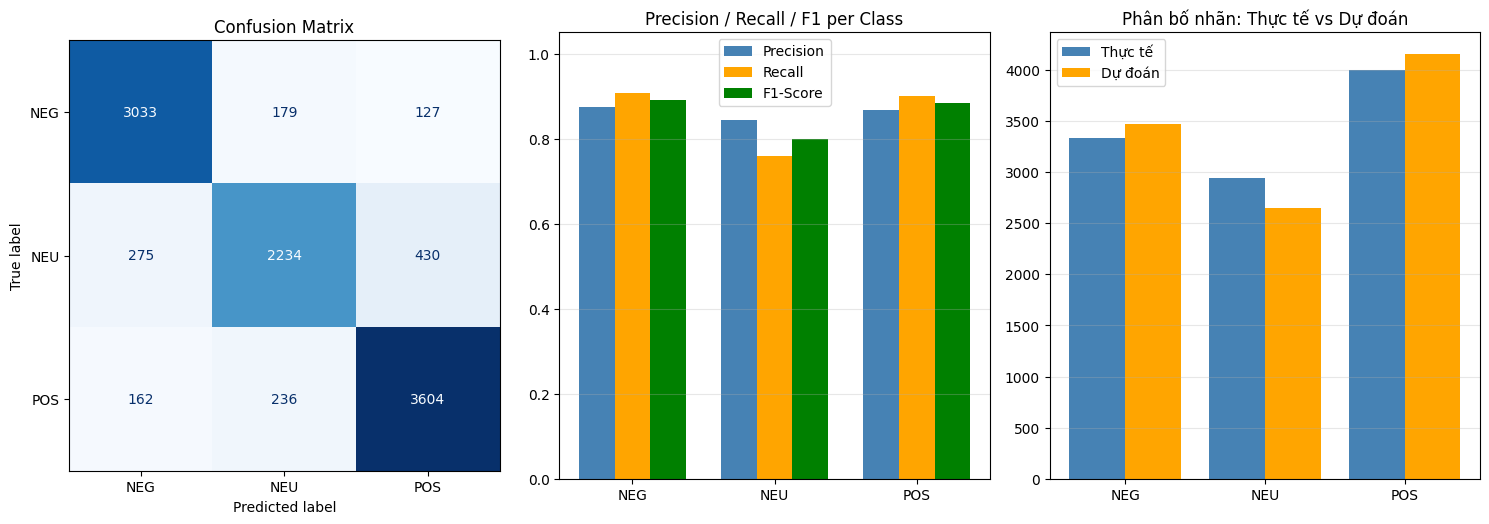

✅ Đã lưu file model_evaluation.png


In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(15, 10))
gs = gridspec.GridSpec(2, 3, figure=fig)

# --- 1: Confusion Matrix ---
ax1 = fig.add_subplot(gs[0, 0])
cm = confusion_matrix(y_test, y_pred, labels=['NEG', 'NEU', 'POS'])
disp = ConfusionMatrixDisplay(cm, display_labels=['NEG', 'NEU', 'POS'])
disp.plot(ax=ax1, colorbar=False, cmap='Blues')
ax1.set_title('Confusion Matrix')

# --- 2: Precision / Recall / F1 per class ---
ax2 = fig.add_subplot(gs[0, 1])
from sklearn.metrics import precision_recall_fscore_support
labels_order = ['NEG', 'NEU', 'POS']
precision, recall, f1, _ = precision_recall_fscore_support(
    y_test, y_pred, labels=labels_order, zero_division=0
)
x = np.arange(len(labels_order))
width = 0.25
ax2.bar(x - width, precision, width, label='Precision', color='steelblue')
ax2.bar(x,         recall,    width, label='Recall',    color='orange')
ax2.bar(x + width, f1,        width, label='F1-Score',  color='green')
ax2.set_xticks(x)
ax2.set_xticklabels(labels_order)
ax2.set_ylim(0, 1.05)
ax2.set_title('Precision / Recall / F1 per Class')
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

# --- 3: Phân bố nhãn thực tế vs dự đoán ---
ax3 = fig.add_subplot(gs[0, 2])
actual_counts = y_test.value_counts().reindex(labels_order)
pred_counts   = pd.Series(y_pred).value_counts().reindex(labels_order)
x = np.arange(len(labels_order))
ax3.bar(x - 0.2, actual_counts, 0.4, label='Thực tế', color='steelblue')
ax3.bar(x + 0.2, pred_counts,   0.4, label='Dự đoán', color='orange')
ax3.set_xticks(x)
ax3.set_xticklabels(labels_order)
ax3.set_title('Phân bố nhãn: Thực tế vs Dự đoán')
ax3.legend()
ax3.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('model_evaluation.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Đã lưu file model_evaluation.png")

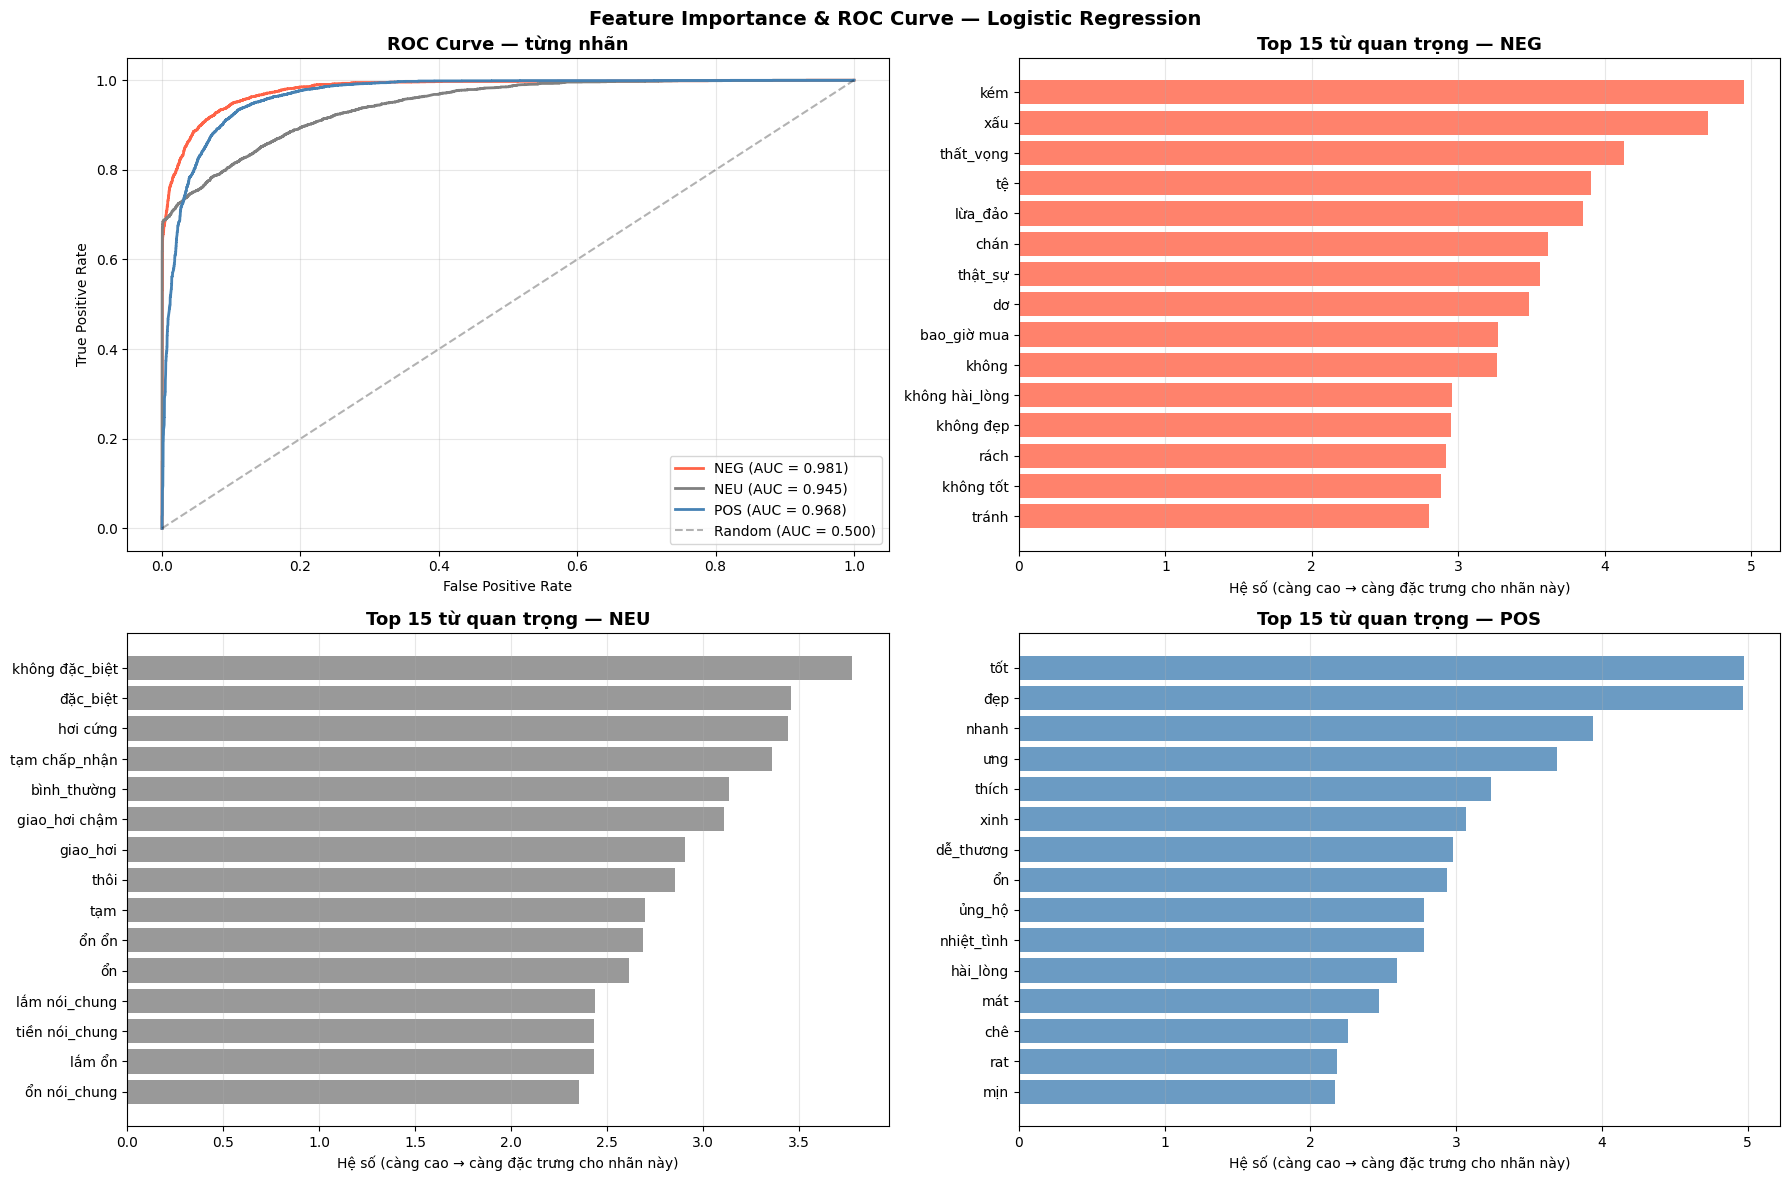

In [13]:
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(18, 12), squeeze=False)

# ============================================================
# Biểu đồ 1 (trên trái): ROC Curve
# ============================================================
ax1 = axes[0, 0]

y_test_bin = label_binarize(y_test, classes=['NEG', 'NEU', 'POS'])
X_test_tfidf = pipeline['tfidf'].transform(X_test) # Re-create X_test_tfidf using the pipeline's tfidf
y_prob     = pipeline['clf'].predict_proba(X_test_tfidf) # Use pipeline['clf'] instead of model

colors = ['tomato', 'gray', 'steelblue']
for i, (label, color) in enumerate(zip(['NEG', 'NEU', 'POS'], colors)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob[:, i])
    auc_score   = auc(fpr, tpr)
    ax1.plot(fpr, tpr, color=color, linewidth=2,
             label=f'{label} (AUC = {auc_score:.3f})')

ax1.plot([0,1], [0,1], 'k--', alpha=0.3, label='Random (AUC = 0.500)')
ax1.set_title('ROC Curve — từng nhãn', fontsize=13, fontweight='bold')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.legend()
ax1.grid(True, alpha=0.3)

# ============================================================
# Hàm vẽ feature importance
# ============================================================
feature_names = np.array(pipeline['tfidf'].get_feature_names_out()) # Use pipeline['tfidf'] instead of tfidf
classes       = list(pipeline['clf'].classes_) # Use pipeline['clf'] instead of model

def plot_top_features(ax, class_name, color, top_n=15):
    idx       = classes.index(class_name)
    coef      = pipeline['clf'].coef_[idx] # Use pipeline['clf'] instead of model
    top_idx   = np.argsort(coef)[-top_n:]
    top_words = feature_names[top_idx]
    top_vals  = coef[top_idx]
    ax.barh(top_words, top_vals, color=color, alpha=0.8)
    ax.set_title(f'Top {top_n} từ quan trọng — {class_name}',
                 fontsize=13, fontweight='bold')
    ax.set_xlabel('Hệ số (càng cao → càng đặc trưng cho nhãn này)')
    ax.grid(axis='x', alpha=0.3)




# Biểu đồ 2 (trên phải): NEG
plot_top_features(axes[0, 1], 'NEG', 'tomato')

# Biểu đồ 3 (dưới trái): NEU
plot_top_features(axes[1, 0], 'NEU', 'gray')

# Biểu đồ 4 (dưới phải): POS
plot_top_features(axes[1, 1], 'POS', 'steelblue')

plt.suptitle('Feature Importance & ROC Curve — Logistic Regression',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('feature_roc.png', dpi=150, bbox_inches='tight')
plt.show()

In [14]:
#Lưu
with open('sentiment_pipeline.pkl', 'wb') as f:
    pickle.dump(pipeline, f)
print("\n💾 Model đã lưu: sentiment_pipeline.pkl")

# --- 4.7: Hàm predict tiện dụng ---
def predict_sentiment(texts: list[str]) -> list[str]:
    """Nhận list câu, trả về list nhãn POS/NEG."""
    return pipeline.predict(texts).tolist()

# Ví dụ
samples = ["sản phẩm rất tệ", "hàng chất lượng"]
print(f"\n🧪 Demo: {predict_sentiment(samples)}")


💾 Model đã lưu: sentiment_pipeline.pkl

🧪 Demo: ['NEG', 'POS']


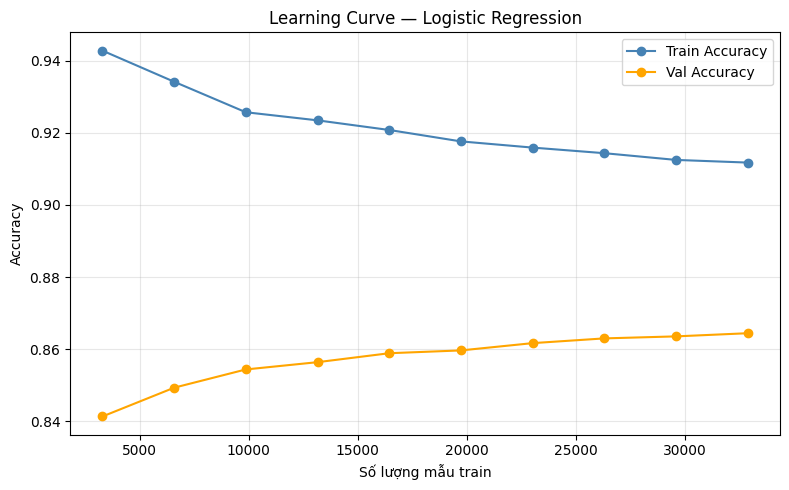

In [15]:
from sklearn.model_selection import learning_curve
import numpy as np
import matplotlib.pyplot as plt

X_train_tfidf = pipeline['tfidf'].transform(X_train)

train_sizes, train_scores, val_scores = learning_curve(
    LogisticRegression(C=1.0, max_iter=1000, class_weight='balanced'),
    X_train_tfidf, y_train,
    train_sizes=np.linspace(0.1, 1.0, 10),
    cv=5,
    scoring='accuracy',
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean   = val_scores.mean(axis=1)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, train_mean, 'o-', color='steelblue', label='Train Accuracy')
plt.plot(train_sizes, val_mean,   'o-', color='orange',    label='Val Accuracy')
plt.title('Learning Curve — Logistic Regression')
plt.xlabel('Số lượng mẫu train')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('learning_curve.png', dpi=150, bbox_inches='tight')
plt.show()